# Bank Customer Segmentation & Term Deposit Subscription Prediction

## Project Overview
This notebook analyzes the **Bank Marketing Dataset** (41,188 customers) to:
1. **Predict** which customers are likely to subscribe to a term deposit (classification)
2. **Segment** customers into meaningful groups for targeted marketing (clustering)

## Dataset
- Source: UCI Bank Marketing Dataset (`bank-additional-full.csv`)
- Target variable: `y` — whether the customer subscribed to a term deposit (`yes`/`no`)
- **Class imbalance:** ~89% `no`, ~11% `yes` — addressed via `class_weight='balanced'` and stratified splitting

## Notebook Structure
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Classification models (Logistic Regression, Random Forest, Decision Tree)
4. Customer segmentation (KMeans clustering)
5. SQL analysis
6. Final conclusions & business recommendations

> **Note on `duration`:** Dropped because it leaks future information — call duration is only known *after* the call ends, so it cannot be used for prediction at campaign time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset/bank-additional-full.csv", sep=';')  
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
df.info()
df.describe()
df['y'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

y
no     36548
yes     4640
Name: count, dtype: int64

In [3]:
df = df.replace("unknown", None)

In [4]:
df['pdays'] = df['pdays'].replace(999, -1)

In [5]:
df = df.drop(columns=['duration'])

In [6]:
# 1. Subscription vs Job

job_sub = pd.crosstab(df['job'], df['y'])
print(job_sub)

# percentage view (better for insights)
job_sub_pct = pd.crosstab(df['job'], df['y'], normalize='index') * 100
print(job_sub_pct)

y                no   yes
job                      
admin.         9070  1352
blue-collar    8616   638
entrepreneur   1332   124
housemaid       954   106
management     2596   328
retired        1286   434
self-employed  1272   149
services       3646   323
student         600   275
technician     6013   730
unemployed      870   144
y                     no        yes
job                                
admin.         87.027442  12.972558
blue-collar    93.105684   6.894316
entrepreneur   91.483516   8.516484
housemaid      90.000000  10.000000
management     88.782490  11.217510
retired        74.767442  25.232558
self-employed  89.514426  10.485574
services       91.861930   8.138070
student        68.571429  31.428571
technician     89.173958  10.826042
unemployed     85.798817  14.201183


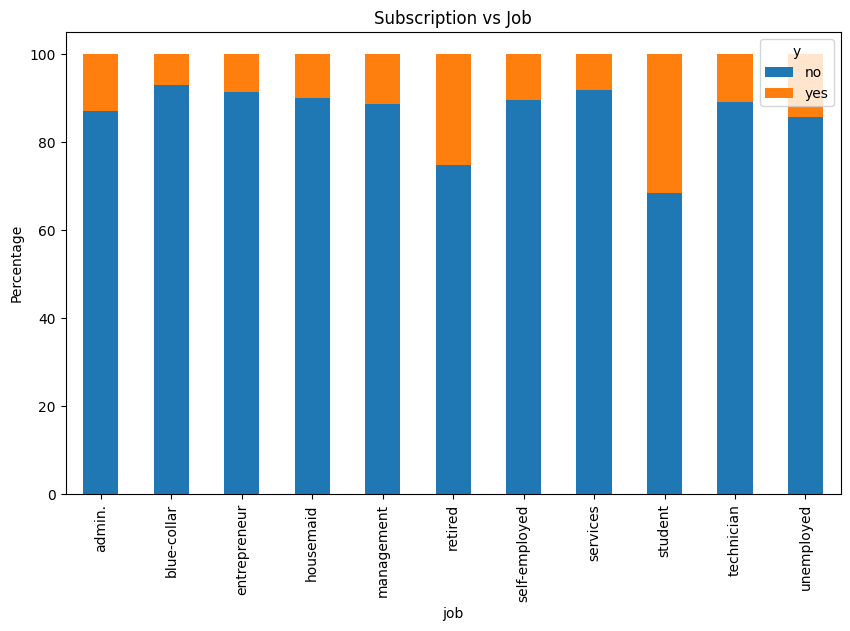

In [7]:
job_sub_pct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Subscription vs Job")
plt.ylabel("Percentage")
plt.show()

### 🔍 Insights:
- Students (31.43%) and retired individuals (25.23%) show the highest subscription rates among all job categories.
- Blue-collar workers (6.89%) and services employees (8.14%) have the lowest subscription rates.
- Most other professions (admin, technician, management) fall in a moderate range of around 10–13%.
- This indicates that lifestyle, financial stability, or availability may influence the likelihood of subscribing.

### 💡 Business Recommendation:
- Focus marketing efforts on students and retired customers, as they are the most responsive segments.
- Develop targeted strategies (e.g., customized offers or messaging) to improve engagement among blue-collar and service workers.
- Maintain steady campaigns for mid-performing groups like admin and technicians to gradually increase conversion rates.

In [ ]:
# 2. Subscription vs Age

bins = [0, 25, 40, 60, 100]
labels = ['Young', 'Adult', 'Middle Age', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_sub = pd.crosstab(df['age_group'], df['y'], normalize='index') * 100
print(age_sub)

In [ ]:
age_sub.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Subscription vs Age Group")
plt.ylabel("Percentage")
plt.show()

### 🔍 Insights:
- Senior customers have the highest subscription rate (45.49%), significantly higher than all other age groups.
- Young customers show a moderate response rate (20.95%), higher than adult and middle-aged groups.
- Adult (10.73%) and middle-aged customers (9.12%) have comparatively lower subscription rates.
- This suggests that older individuals are more inclined toward term deposit subscriptions, possibly due to financial stability or savings-oriented behavior.

### 💡 Business Recommendation:
- Prioritize senior customers in marketing campaigns, as they are the most responsive segment.
- Target young customers with tailored offers to further improve their already moderate engagement.
- Re-evaluate strategies for adult and middle-aged groups, possibly by offering more attractive or flexible financial products.
  

In [ ]:
# 3. Subscription vs Contact

contact_sub = pd.crosstab(df['contact'], df['y'], normalize='index') * 100
print(contact_sub)

In [ ]:
contact_sub.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Subscription vs Contact Type")
plt.ylabel("Percentage")
plt.show()

### 🔍 Insights:
- Customers contacted via cellular have a significantly higher subscription rate (14.74%) compared to telephone (5.23%).
- Telephone contact shows a very low conversion rate, indicating lower effectiveness.
- This suggests that customers are more responsive to mobile-based communication channels.

### 💡 Business Recommendation:
- Prioritize cellular contact methods for marketing campaigns to improve conversion rates.
- Reduce reliance on telephone-based outreach or redesign the approach to make it more engaging.
- Invest in mobile-based marketing strategies such as SMS, app notifications, or personalized calls.

In [ ]:
# Marital status

marital_status= pd.crosstab(df['marital'], df['y'], normalize='index') * 100
print(marital_status)



In [ ]:
marital_status.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Subscription vs Marital status")
plt.ylabel("Percentage")
plt.show()

### 🔍 Insights:
- Single customers have the highest subscription rate (14.00%) compared to married (10.16%) and divorced (10.32%) individuals.
- Married and divorced groups show very similar and lower response rates.
- This indicates that single individuals may be more open to financial products or investment opportunities.

### 💡 Business Recommendation:
- Target single customers more aggressively, as they are the most responsive segment.
- Design tailored marketing campaigns for married and divorced customers to improve engagement, possibly highlighting family or long-term financial benefits.
- Segment messaging based on marital status to better align with customer needs and motivations.

In [ ]:
# Education
education = pd.crosstab(df['education'], df['y'], normalize='index') * 100
print(education)



In [ ]:
education.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Subscription vs Education")
plt.ylabel("Percentage")
plt.show()

### 🔍 Insights:
- Illiterate customers show a relatively high subscription rate (22.22%), though this group is likely very small in size.
- Among the larger groups, customers with a university degree (13.72%) have the highest subscription rate.
- High school (10.84%) and professional course (11.35%) groups show moderate performance.
- Basic education levels (basic.6y: 8.20%, basic.9y: 7.82%) have the lowest subscription rates.
- Overall, higher education levels tend to be associated with better subscription rates.

### 💡 Business Recommendation:
- Focus on customers with higher education (especially university degree holders), as they show stronger engagement.
- Be cautious when interpreting the illiterate category due to likely low sample size.
- Develop simplified and more accessible marketing strategies for lower-education groups to improve their response rates.

In [ ]:
# Housing loan
house_loan= pd.crosstab(df['housing'], df['y'], normalize='index') * 100
print(house_loan)


In [ ]:
house_loan.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Subscription vs Housing loan")
plt.ylabel("Percentage")
plt.show()

### 🔍 Insights:
- Customers with housing loans (11.62%) have a slightly higher subscription rate compared to those without housing loans (10.88%).
- However, the difference between the two groups is very small, indicating that housing loan status is not a strong differentiating factor for subscription.
- Overall, both groups show similar behavior in terms of subscription likelihood.

### 💡 Business Recommendation:
- Housing loan status alone should not be considered a key targeting factor for campaigns.
- Instead, it should be combined with other stronger predictors (such as age, job, and contact type) for better segmentation.
- Marketing strategies should focus more on high-impact variables rather than relying on housing loan status.

In [ ]:
# Personal loan
Personal_loan = pd.crosstab(df['loan'], df['y'], normalize='index') * 100
print(Personal_loan)

In [ ]:
Personal_loan.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Subscription vs Personal loan")
plt.ylabel("Percentage")
plt.show()

### 🔍 Insights:
- Customers without personal loans (11.34%) have a slightly higher subscription rate than those with personal loans (10.93%).
- The difference between the two groups is minimal, indicating that personal loan status does not strongly influence subscription behavior.
- Both groups show almost identical response patterns.

### 💡 Business Recommendation:
- Personal loan status should not be used as a primary segmentation factor for targeting customers.
- It should be combined with stronger predictors like age, job type, and previous campaign outcome for better targeting.
- Marketing resources should be prioritized toward variables that show higher variation in subscription rates.

In [ ]:
poutcome = pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100
print(poutcome)

In [ ]:
poutcome.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Subscription vs Previous Campaign Outcome")
plt.ylabel("Percentage")
plt.show()

### 🔍 Insights:
- Customers with a previous successful campaign outcome show a very high subscription rate (65.11%), which is significantly higher than all other groups.
- Customers with previous failure outcomes have a moderate subscription rate (14.23%).
- The majority of customers fall under the "nonexistent" category (no previous campaign contact), but their subscription rate is relatively low (8.83%).
- This clearly shows that previous campaign success is the strongest predictor of future subscription behavior.

### 💡 Business Recommendation:
- Prioritize customers with a "success" outcome in previous campaigns, as they have a very high likelihood of subscribing again.
- Re-engage customers with past failures using improved targeting strategies or personalized offers.
- Design separate marketing strategies for new (nonexistent) customers, as they require more effort to convert.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('y_yes', axis=1)
y = df['y_yes']

# random_state=42 ensures reproducibility across runs
# stratify=y preserves the 89/11 class ratio in both train and test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' auto-adjusts weights inversely proportional to class frequency
# This compensates for the ~89/11 imbalance so the model doesn't just predict 'No' always
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' handles imbalance; random_state for reproducibility
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# max_depth=8 prevents overfitting (unpruned trees memorize training data)
# min_samples_leaf=20 ensures each leaf represents a meaningful number of customers
# class_weight='balanced' handles the class imbalance
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced'
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
y_pred_lr = model.predict(X_test_scaled)

print("LR Accuracy: ",(accuracy_score(y_test, y_pred_lr)))
print(classification_report(y_test, y_pred_lr))

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

In [ ]:
print("DT Accuracy: ", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

In [ ]:
from sklearn.metrics import roc_auc_score

lr_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

print("=== ROC-AUC Scores (better metric for imbalanced classification) ===")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"Decision Tree AUC:       {dt_auc:.4f}")

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('Decision Tree',       y_pred_dt)
]

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrices — all models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from Random Forest (most reliable of the three models)
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = feat_imp.nlargest(15).sort_values()

plt.figure(figsize=(8, 6))
top15.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.nlargest(10).round(4))

### Model Comparison

Run all cells above to populate actual values in the printed output. Summary guide:

| Model | Strength | Best Use Case |
| --- | --- | --- |
| Logistic Regression | High interpretability, good recall with balanced weights | Explaining decisions to stakeholders |
| Random Forest | Best AUC, robust to overfitting | Production prediction, feature importance |
| Decision Tree (pruned) | Explainable rules, fast inference | Rule extraction, simple deployment |

### Key Notes
- All models use `class_weight='balanced'` — this improves recall for the minority (`yes`) class
- Use **ROC-AUC** as the primary metric for imbalanced classification, not accuracy
- High accuracy (~90%) can be misleading — a model predicting 'No' always would also score ~89%
- **Recommended model: Random Forest** for best AUC; Logistic Regression if interpretability is required

In [9]:
# Expanded feature set for richer, more actionable customer segments
# Original used only 3 features; adding balance, pdays, and economic indicators
cluster_features = ['age', 'campaign', 'previous', 'balance_' if 'balance_' in df.columns else None]

# Use available numeric-ish columns from the encoded df
available = ['age', 'campaign', 'previous', 'pdays', 'nr.employed', 'euribor3m', 'emp.var.rate']
cluster_features = [f for f in available if f in df.columns]
print("Clustering features:", cluster_features)

X_cluster = df[cluster_features]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

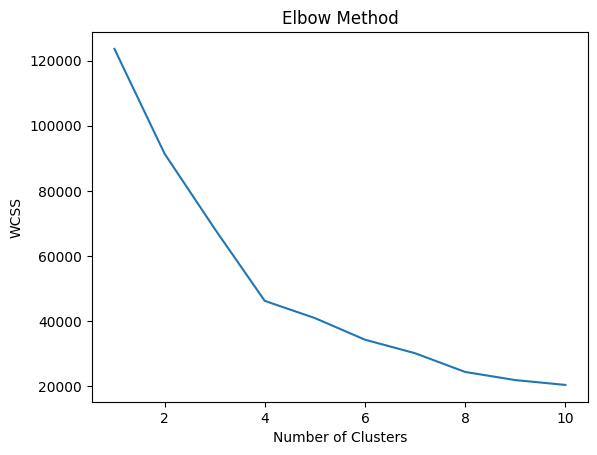

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
# Cluster profile — mean feature values
print("=== Cluster Profiles ===")
print(df.groupby('cluster')[cluster_features].mean().round(2))

# Subscription rate per cluster — connects unsupervised segments to business outcome
print("\n=== Subscription Rate per Cluster ===")
if 'y_yes' in df.columns:
    sub_rate = df.groupby('cluster')['y_yes'].agg(['mean', 'sum', 'count'])
    sub_rate.columns = ['subscription_rate', 'subscribed_count', 'total_count']
    sub_rate['subscription_rate'] = (sub_rate['subscription_rate'] * 100).round(2)
    print(sub_rate)

,age,campaign,previous
cluster,,,
0,39.945040,2.162692,0.000000
1,40.451008,1.923077,1.267357
2,40.185993,12.506889,0.013203


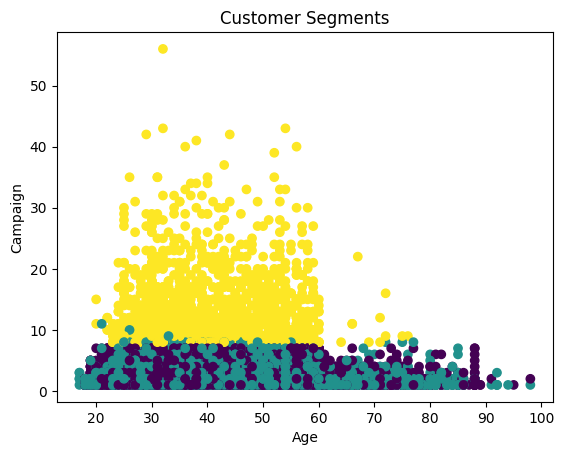

In [15]:
plt.scatter(df['age'], df['campaign'], c=df['cluster'])
plt.xlabel("Age")
plt.ylabel("Campaign")
plt.title("Customer Segments")
plt.show()

### Customer Segmentation Conclusion:

- Cluster 1 is the most valuable segment as it shows previous engagement and moderate campaign response, making them more likely to convert.
- Cluster 0 represents low-engagement customers who require awareness-based or long-term nurturing strategies.
- Cluster 2 represents over-targeted customers with low historical response, indicating inefficient marketing efforts.

### Recommendation:
- Prioritize Cluster 1 for conversion-focused campaigns.
- Reduce marketing spend on Cluster 2 and optimize contact strategy.
- Use Cluster 0 for long-term nurturing rather than direct conversion attempts.

In [16]:
import pandas as pd
import sqlite3

df_raw = pd.read_csv(
    "/kaggle/input/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset/bank-additional-full.csv",
    sep=';'
)

conn = sqlite3.connect(":memory:")
df_raw.to_sql("bank_data", conn, index=False, if_exists="replace")

41188

In [17]:
query = """
SELECT 
    job,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS subscribed,
    ROUND(100.0 * SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS rate
FROM bank_data
GROUP BY job
ORDER BY rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,job,total_customers,subscribed,rate
0,student,875,275,31.43
1,retired,1720,434,25.23
2,unemployed,1014,144,14.20
3,admin.,10422,1352,12.97
4,management,2924,328,11.22
5,unknown,330,37,11.21
6,technician,6743,730,10.83
7,self-employed,1421,149,10.49
8,housemaid,1060,106,10.00
9,entrepreneur,1456,124,8.52


In [19]:
query2 = """
SELECT 
    contact,
    COUNT(*) AS total,
    SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS subscribed,
    ROUND(100.0 * SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS rate
FROM bank_data
GROUP BY contact;
"""

pd.read_sql_query(query2, conn)

,contact,total,subscribed,rate
0,cellular,26144,3853,14.74
1,telephone,15044,787,5.23


## Final Conclusion

### Key Patterns
- Subscription rates vary significantly across job types, with students and retired customers showing higher conversion.
- Age plays an important role, with younger and senior customers being more responsive.
- Cellular contact method performs better than telephone.
- Customers with previous successful interactions are much more likely to subscribe.

### Model Performance
- Logistic Regression, Random Forest, and Decision Tree models were evaluated.
- Random Forest achieved the highest recall for the subscriber class, making it the most suitable model.
- Logistic Regression showed better overall balance but lower recall for identifying subscribers.

### Customer Segmentation
- Clustering revealed three customer groups:
  - Low engagement customers with minimal interaction history.
  - Moderately engaged customers with some previous contact.
  - Highly contacted but low-response customers.
- These segments help in designing targeted marketing strategies.

### Business Recommendations
- Focus marketing efforts on customers with prior engagement and positive history.
- Use cellular communication as the primary contact method.
- Avoid excessive repeated campaigns for low-response customers.
- Apply targeted strategies for different customer segments to improve conversion rates.

### Final Insight
This project combines predictive modeling and customer segmentation to both forecast customer behavior and understand customer groups, enabling more effective and data-driven marketing decisions.